## 1. Importar bibliotecas

In [1]:
# Importar bibliotecas
import yfinance as yf
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import date
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Coletar dados

In [2]:
# Ticker da empresa
ticker = 'VALE3.SA'
start_date = '2024-01-01'
end_date = date.today()

In [3]:
# Baixar dados históricos de preço
df = yf.download(ticker, start=start_date, end=end_date)
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-01-02,77.599998,78.180000,76.589996,77.050003,71.151764,18021800
2024-01-03,76.709999,76.900002,75.849998,76.650002,70.782379,25315100
2024-01-04,76.430000,76.639999,75.360001,75.620003,69.831230,18707000
2024-01-05,75.029999,75.050003,74.120003,74.650002,68.935486,21082500
2024-01-08,73.940002,74.559998,73.510002,74.269997,68.584572,23013300


## 3. Processar dados

In [4]:
# Tratar valores ausentes
df = df.dropna()

In [5]:
# Setar variáveis
feature = df['Close']

In [6]:
# Criação de features para médias móveis
df['SMA_10'] = feature.rolling(window = 10).mean()
df['SMA_50'] = feature.rolling(window = 50).mean()
df['SMA_200'] = feature.rolling(window = 200).mean()

In [7]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,SMA_10,SMA_50,SMA_200
Date,,,,,,,,,
2024-01-02,77.599998,78.180000,76.589996,77.050003,71.151764,18021800,NaN,NaN,NaN
2024-01-03,76.709999,76.900002,75.849998,76.650002,70.782379,25315100,NaN,NaN,NaN
2024-01-04,76.430000,76.639999,75.360001,75.620003,69.831230,18707000,NaN,NaN,NaN
2024-01-05,75.029999,75.050003,74.120003,74.650002,68.935486,21082500,NaN,NaN,NaN
2024-01-08,73.940002,74.559998,73.510002,74.269997,68.584572,23013300,NaN,NaN,NaN


In [8]:
# Normalizar os dados
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Close']])
df_scaled

array([[1.        ],
       [0.98099755],
       [0.9320665 ],
       [0.88598569],
       [0.86793321],
       [0.82327788],
       [0.77102143],
       [0.78907355],
       [0.74536818],
       [0.73871738],
       [0.69453685],
       [0.63420411],
       [0.61757711],
       [0.5748217 ],
       [0.56057013],
       [0.62707815],
       [0.66033252],
       [0.57862226],
       [0.64133007],
       [0.62565303],
       [0.60712574],
       [0.55866985],
       [0.54394277],
       [0.47885988],
       [0.45178151],
       [0.5068882 ],
       [0.5130642 ],
       [0.48503552],
       [0.47125875],
       [0.46175771],
       [0.45178151],
       [0.57007118],
       [0.54584305],
       [0.47553447],
       [0.49928744],
       [0.53301661],
       [0.54061737],
       [0.46318283],
       [0.54536825],
       [0.5102136 ],
       [0.52209008],
       [0.5168644 ],
       [0.5097388 ],
       [0.46793335],
       [0.51068876],
       [0.49976224],
       [0.47553447],
       [0.378

## 4. Primeiros passos com LSTM

In [9]:
# Séries temporais
def create_serie(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(np.array(x))
        ys.append(np.array(y))
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 50 # tamanha da série
x, y = create_serie(df_scaled, SEQ_LENGTH)

# Dividindo dados entre treino e teste
split = int(0.8 * len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:] 

### 4.1 Construir modelo

In [10]:
# Construindo o modelo LSTM
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(1))  # Saída única para o preço de fechamento

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Treinando o modelo
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))


c:\Users\55119\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - loss: 0.0636 - val_loss: 0.0129
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0113 - val_loss: 0.0098
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0116 - val_loss: 0.0113
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0088 - val_loss: 0.0127
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0109 - val_loss: 0.0100
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0084 - val_loss: 0.0084
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0080 - val_loss: 0.0083
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0086 - val_loss: 0.0088
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0071 - val_loss: 0.0091
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0066 - val_loss: 0.0087
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0064 - val_loss: 0.0082
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0065 - val_loss: 0.0082


## 5. Avaliar modelo

In [11]:
# Fazendo previsões
y_predict = model.predict(x_test)

mae = mean_absolute_error(y_test, y_predict)
rmse = np.sqrt(mean_squared_error(y_test, y_predict))

print(f'MAE: {mae}, RMSE: {rmse}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
MAE: 0.06494337064146727, RMSE: 0.08922421958721734


In [12]:
y_predict = scaler.inverse_transform(y_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

In [13]:
def predict_future(model, last_data, days):
    predictions = []

    # Redimensionar last_data para (1, SEQ_LENGTH, 1)
    last_data_reshaped = last_data.reshape((1, last_data.shape[0], 1))

    for _ in range(days):
        prediction = model.predict(last_data_reshaped)  # Prever o próximo valor
        predictions.append(prediction[0][0])  # Armazenar a previsão
        
        # Verificar formas antes da concatenação
        print("last_data_reshaped shape:", last_data_reshaped.shape)
        print("prediction shape:", prediction.shape)
        
        # Atualiza last_data para a próxima previsão
        # Converte a previsão para o formato correto
        prediction_reshaped = prediction.reshape(1, 1, 1)  # Formato (1, 1, 1)
        
        # Mantém as dimensões
        last_data_reshaped = np.append(last_data_reshaped[:, 1:, :], prediction_reshaped, axis=1)  

        # Verifique a forma após a atualização
        print("Updated last_data_reshaped shape:", last_data_reshaped.shape)

    return predictions


In [14]:
# Os últimos dados do conjunto de teste
last_test_data = x_test[-1]

In [15]:
# Previsões para 5, 10, 15 e 20 dias
predictions_5_days = predict_future(model, last_test_data, 5)
predictions_10_days = predict_future(model, last_test_data, 10)
predictions_15_days = predict_future(model, last_test_data, 15)
predictions_20_days = predict_future(model, last_test_data, 20)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
last_data_reshaped shape: (1, 50, 1)
prediction shape: (1, 1)
Updated last_data_reshaped shape: (1, 50, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
last_data_reshaped shape: (1, 50, 1)
prediction shape: (1, 1)
Updated last_data_reshaped shape: (1, 50, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
last_data_reshaped shape: (1, 50, 1)
prediction shape: (1, 1)
Updated last_data_reshaped shape: (1, 50, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
last_data_reshaped shape: (1, 50, 1)
prediction shape: (1, 1)
Updated last_data_reshaped shape: (1, 50, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
last_data_reshaped shape: (1, 50, 1)
prediction shape: (1, 1)
Updated last_data_reshaped shape: (1, 50, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
last_data_reshaped shape: (1, 50, 1)
prediction shape: (1, 1)
Updated last_data_reshaped shape: (1, 50, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
last_data_reshaped shape: (1, 50, 1)
prediction shape: (1, 1)
Updated last_data_reshaped sh

In [16]:

# Transformar as previsões de volta à escala original
predictions_5_days = scaler.inverse_transform(np.array(predictions_5_days).reshape(-1, 1))
predictions_10_days = scaler.inverse_transform(np.array(predictions_10_days).reshape(-1, 1))
predictions_15_days = scaler.inverse_transform(np.array(predictions_15_days).reshape(-1, 1))
predictions_20_days = scaler.inverse_transform(np.array(predictions_20_days).reshape(-1, 1))

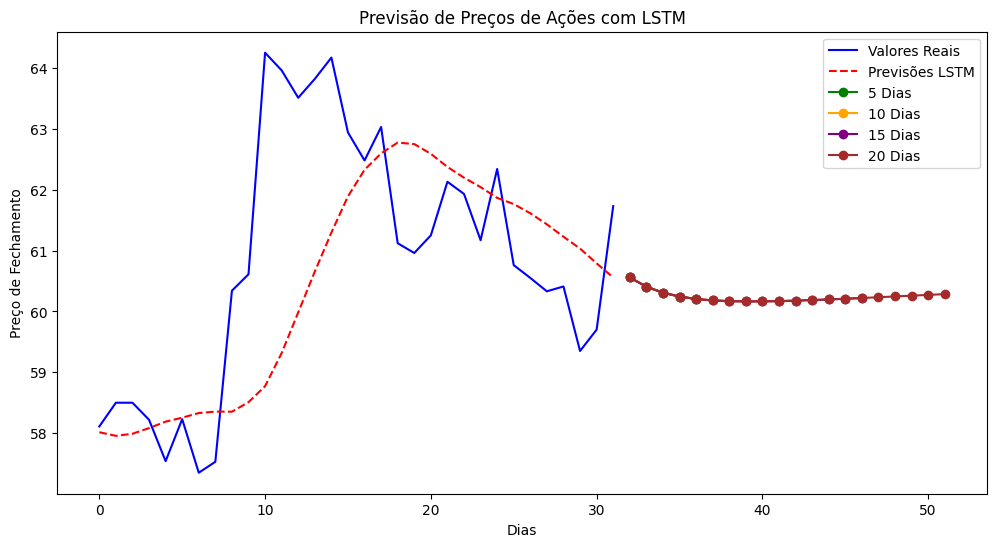

In [17]:
# Plotar os dados
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Valores Reais', color='blue')
plt.plot(y_predict, label='Previsões LSTM', color='red', linestyle='dashed')

# Adicionar previsões futuras ao gráfico
plt.plot(range(len(y_test), len(y_test) + 5), predictions_5_days, marker='o', label='5 Dias', color='green')
plt.plot(range(len(y_test), len(y_test) + 10), predictions_10_days, marker='o', label='10 Dias', color='orange')
plt.plot(range(len(y_test), len(y_test) + 15), predictions_15_days, marker='o', label='15 Dias', color='purple')
plt.plot(range(len(y_test), len(y_test) + 20), predictions_20_days, marker='o', label='20 Dias', color='brown')

plt.title('Previsão de Preços de Ações com LSTM')
plt.xlabel('Dias')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.show()

## 6. Salvar modelo

In [18]:
model.save('lstm.h5')